This notebook is aimed at fraud detection EDA and the performace of XGBoost on the data. The notebook tries to identify patterns to help understand the characteristics of Fraudulent Transactions.

This was a part of a hackathon and the whole code along with the frontend can be found here: https://github.com/Bella-ciaoo/BerTrugS/tree/main?tab=readme-ov-file

# Summary from Research paper and our manual data analysis

Manual Data Research:
1. all frauds are of type 'CASH_OUT' and 'TRANSFER'. Get rid of all other transactions in dataset.
2. while making transfer, old balance cannot be 0. Anomaly
3. Final amt and initial amt must differ by transaction amount.
4. Same applies for sender.
5. Create new col which have the error value of (transfer) - (mod(send amt - rec amt))

# Account A->Account B-> Account C (Misleading)

There was a hypothesis if the fraud transactions were using a shell account to pass the data, which was later proved false.

a->b transactions are not -> transfers -> flagged
b-> c transactions are -> cash outs -> not able to flag


We have proved this BY TAKING INTERSECTION OF ACC IDS

In [ ]:
df_fraud=df[df["isFraud"]==1]
set1=set(df_fraud["nameOrig"].values.tolist())
set2=set(df_fraud["nameDest"].values.tolist())
l=set1.intersection(set2)
l

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns
import pickle
# for plotting graph in jupyter cell
%matplotlib inline

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AIML Dataset.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Preprocessing

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

#### We will now create 4 lists of the given data namely:

L1) The hour when fraud happened

L2) total trnascations then 

L3) fraud transactions

L4) valid transactions
 

In [ ]:
len(l1)
#-

743

we have 743 hours' data

### Plots of the above data

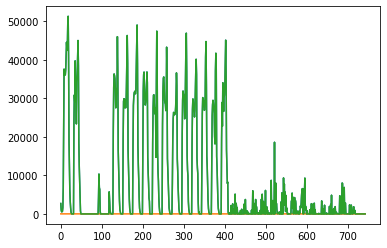

In [ ]:
# plt.figure(figsize=(20, 50))
# these
plt.plot(l2,)


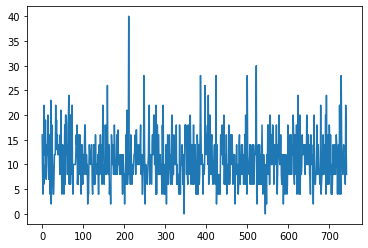

In [ ]:
plt.plot(l3)

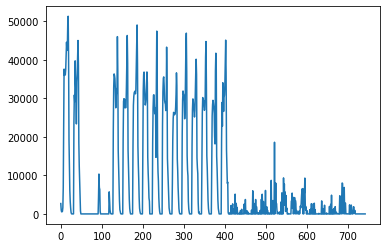

In [ ]:
plt.plot(l4)

Day wise seperation of data

In [ ]:
def get_day_data(df):
    day = []
    val = 1
    for i in df["hour"]:
        day.append(val)
        if i % 24 == 0:
            val += 1
    return day

day = get_day_data(fraud_tx_per_hour)

fraud_tx_per_hour["day"] = day
fraud_tx_per_hour

,hour,total_tx,fraud_tx,valid_tx,day
0,1,2708,16,2692,1
1,2,1014,8,1006,1
2,3,552,4,548,1
3,4,565,10,555,1
4,5,665,6,659,1
...,...,...,...,...,...
738,739,10,10,0,31
739,740,6,6,0,31
740,741,22,22,0,31
741,742,14,14,0,31


## Hour wise plot

In [ ]:
def fraud_per_hour(df):
    l1, l2, l3, l4 = [], [], [], []
    
    for h in df["step"].unique():
        t_df = df.loc[df["step"] == h]
        l1.append(h)
        l2.append(t_df.shape[0])
        l3.append(t_df.loc[t_df["isFraud"] == 1].shape[0])
        l4.append(t_df.loc[t_df["isFraud"] == 0].shape[0])
        
    return (l1, l2, l3, l4)

# getting generated list of Data
l1, l2, l3, l4 = fraud_per_hour(df)

# Create a new DataFrame
fraud_tx_per_hour = pd.DataFrame()

# Add new Columns to the DataFrame
fraud_tx_per_hour["houre"] = l1
fraud_tx_per_hour["total_tx"] = l2
fraud_tx_per_hour["fraud_tx"] = l3
fraud_tx_per_hour["valid_tx"] = l4
fraud_tx_per_hour

,houre,total_tx,fraud_tx,valid_tx
0,1,2708,16,2692
1,2,1014,8,1006
2,3,552,4,548
3,4,565,10,555
4,5,665,6,659
...,...,...,...,...
738,739,10,10,0
739,740,6,6,0
740,741,22,22,0
741,742,14,14,0


In [ ]:
fraud_tx_per_hour["fraud_tx"].describe()

count    743.000000
mean      11.053836
std        4.998631
min        0.000000
25%        8.000000
50%       10.000000
75%       14.000000
max       40.000000
Name: fraud_tx, dtype: float64

## Visualization Insights
1. Fraud are low corelated to time
2. CASH_OUT outweighs the number of TRANSFER in normal transactions
3. In fraudulent transactions the number of CASH_OUT and Transfer is same.  
4. error in transaction(new col) is best parameter

# **Final Breakdown- data preprocessing:**

### Preprocesssing & Feature Engeenering



---



---



In [ ]:
fraudTransactions = df.loc[df.isFraud == 1].type.drop_duplicates().values 
print(list(fraudTransactions))

['TRANSFER', 'CASH_OUT']


In [ ]:
dfTransactions = df.loc[(df.type == 'TRANSFER') | (df.type == 'CASH_OUT')] 
dfFraud = dfTransactions['isFraud']
del dfTransactions['isFraud']

In [ ]:
dfFraud.head()

2     1
3     1
15    0
19    0
24    0
Name: isFraud, dtype: int64

In [ ]:
dfTransactions.loc[dfTransactions.type == 'TRANSFER', 'type'] = 0 
dfTransactions.loc[dfTransactions.type == 'CASH_OUT', 'type'] = 1 
dfTransactions.type = dfTransactions.type.astype(int)

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1763: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)
/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:5170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [ ]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,0
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0


In [ ]:
dfTransactionsFraud = dfTransactions.loc[dfFraud == 1] 
dfTransactionsNonFraud = dfTransactions.loc[dfFraud == 0] 
fractionAnomalyTransactionsInFraud = len(dfTransactionsFraud.loc[
                                                                (dfTransactionsFraud.oldbalanceDest == 0)
                                                                & (dfTransactionsFraud.newbalanceDest == 0) 
                                                                & (dfTransactionsFraud.amount)
                                                                ]) / (1.0 * len(dfTransactionsFraud)) 
print("Part of anomaly transactions among fraudulent: ",fractionAnomalyTransactionsInFraud )
fractionAnomalyTransactionsInNonFraud = len(dfTransactionsNonFraud.loc[ (dfTransactionsNonFraud.oldbalanceDest == 0) & (dfTransactionsNonFraud.newbalanceDest == 0) & (dfTransactionsNonFraud.amount) ]) / (1.0 * len(dfTransactionsNonFraud)) 
print("Part of anomaly transactions among regular (non-fraudulent): ",fractionAnomalyTransactionsInNonFraud )

Part of anomaly transactions among fraudulent:  0.4955558261293072
Part of anomaly transactions among regular (non-fraudulent):  0.0006176245277308345


In [ ]:
dfTransactions.loc[
                   (dfTransactions.oldbalanceDest == 0) 
                   & (dfTransactions.newbalanceDest == 0) 
                   & (dfTransactions.amount != 0),  
                   ['oldbalanceDest', 'newbalanceDest']] = - 1

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1763: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [ ]:
dfTransactions.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
6362615,743,1,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,0
6362616,743,0,6311409.28,C1529008245,6311409.28,0.0,C1881841831,-1.00,-1.00,0
6362617,743,1,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,0
6362618,743,0,850002.52,C1685995037,850002.52,0.0,C2080388513,-1.00,-1.00,0
6362619,743,1,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,0


In [ ]:
dfTransactions.loc[ 
                   (dfTransactions.oldbalanceOrg == 0)
                   & (dfTransactions.newbalanceOrig == 0) & (dfTransactions.amount != 0), 
                   ['oldbalanceOrg', 'newbalanceOrig']] = np.nan

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1763: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [ ]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,-1.0,-1.00,0
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0


In [ ]:
dfTransactions['errorbalanceDest'] = dfTransactions.oldbalanceDest + dfTransactions.amount - dfTransactions.newbalanceDest
dfTransactions['errorbalanceOrig'] = dfTransactions.newbalanceOrig + dfTransactions.amount - dfTransactions.oldbalanceOrg

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,errorbalanceDest,errorbalanceOrig
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,-1.0,-1.00,0,181.0,0.00
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0,21363.0,0.00
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,182703.5,213808.94
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,237735.3,214605.30
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-2401220.0,300850.89


### **Model Charecteristics**

In [ ]:
dfTransactions = dfTransactions.drop( ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1)

In [ ]:
dfTransactions.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
2,1,0,181.00,181.0,0.0,-1.0,-1.00,181.0,0.00
3,1,1,181.00,181.0,0.0,21182.0,0.00,21363.0,0.00
15,1,1,229133.94,15325.0,0.0,5083.0,51513.44,182703.5,213808.94
19,1,0,215310.30,705.0,0.0,22425.0,0.00,237735.3,214605.30
24,1,0,311685.89,10835.0,0.0,6267.0,2719172.89,-2401220.0,300850.89


In [ ]:
list(dfTransactions)

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'errorbalanceDest',
 'errorbalanceOrig']

### Model training

In [ ]:
randomState = 5
np.random.seed(randomState)
trainX, testX, trainY, testY = train_test_split(dfTransactions, dfFraud, test_size = 0.2, random_state = randomState )

In [ ]:
weights = (dfFraud == 0).sum() / (1.0 * (dfFraud == 1).sum()) 
classifier = XGBClassifier(max_depth = 3, scale_pos_weight = weights, n_jobs = 4)
predictions = classifier.fit(trainX, trainY).predict_proba(testX) 

### Model Validation

In [ ]:
from sklearn.metrics import average_precision_score
AURPC = average_precision_score(testY, predictions[:, 1])
AURPC

0.9986361116985445

In [ ]:
preddf=classifier.predict(testX)

In [ ]:
preddf

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report 

print(classification_report(testY,preddf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552412
           1       0.91      1.00      0.95      1670

    accuracy                           1.00    554082
   macro avg       0.95      1.00      0.98    554082
weighted avg       1.00      1.00      1.00    554082



In [ ]:
onerow = pd.DataFrame({'step': [459], 'type': [0], 'amount': [1153156], 'oldbalanceOrg': [1153156]
                       , 'newbalanceOrig': [0], 'oldbalanceDest': [-1], 'newbalanceDest': [-1], 'errorbalanceDest': [1153156]
                       , 'errorbalanceOrig': [0]})

In [ ]:
onerow.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
0,459,0,1153156,1153156,0,-1,-1,1153156,0


In [ ]:
classifier.predict(onerow)

array([1])

In [ ]:
predictions

array([[9.9962318e-01, 3.7682877e-04],
       [9.9944901e-01, 5.5101089e-04],
       [9.9942690e-01, 5.7309744e-04],
       ...,
       [9.9971920e-01, 2.8082289e-04],
       [9.9960637e-01, 3.9365853e-04],
       [9.9964070e-01, 3.5930835e-04]], dtype=float32)

In [ ]:
testX[testX.index==6020168]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
6020168,459,0,1153156.0,1153156.0,0.0,-1.0,-1.0,1153156.0,0.0


In [ ]:
testY[testY==1]

6272989    1
1640528    1
6020168    1
6318843    1
1511381    1
          ..
5248384    1
3594476    1
6259942    1
819544     1
4388729    1
Name: isFraud, Length: 1670, dtype: int64

In [ ]:
testX.shape

(554082, 9)

In [ ]:
print(testX.iloc[0])

step                    205.00
type                      1.00
amount                63243.44
oldbalanceOrg              NaN
newbalanceOrig             NaN
oldbalanceDest      1853683.32
newbalanceDest      1916926.76
errorbalanceDest          0.00
errorbalanceOrig           NaN
Name: 2537487, dtype: float64


In [ ]:
testX.isnull().sum()

step                     0
type                     0
amount                   0
oldbalanceOrg       261654
newbalanceOrig      261654
oldbalanceDest           0
newbalanceDest           0
errorbalanceDest         0
errorbalanceOrig    261654
dtype: int64

In [ ]:
classifier.save_model('5model.bin')

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


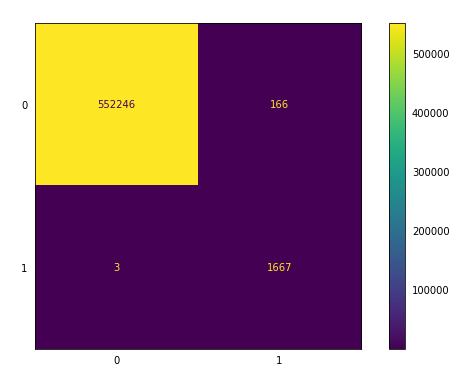

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,plot_confusion_matrix



matrix= plot_confusion_matrix( classifier,testX,testY)
matrix.ax_.set_title('Confusion Matrix',color='white')
plt.xlabel('Predicted label',color='white')
plt.ylabel('True label',color='white')
plt.gcf().axes[0].tick_params(color='white')
plt.gcf().axes[1].tick_params(color='white')
plt.gcf().set_size_inches(10,6)
plt.show()

## AUCROC Plot

In [ ]:
#prediction probabilities
from sklearn.metrics import roc_curve,roc_auc_score
classifier_probs=classifier.predict_proba(testX)
classifier_probs=classifier_probs[:,1]

In [ ]:
#print auroc scores
classifier_auc=roc_auc_score(testY, classifier_probs)

In [ ]:
#calculate roc curve
classifier_fpr,classifier_tpr,_=roc_curve(testY,classifier_probs)

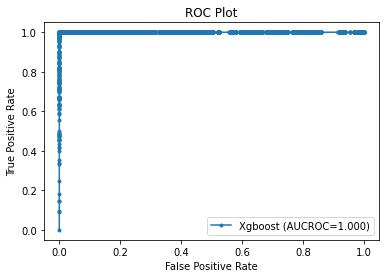

In [ ]:
plt.plot(classifier_fpr,classifier_tpr,marker='.',label='Xgboost (AUCROC=%0.3f)'%classifier_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Outliers


In [ ]:
outliers=[]
def detect_outliers(dfTransactions):
  threshold=3
  mean=np.mean(dfTransactions)
  std=np.mean(dfTransactions)
  for i in dfTransactions:
    z_score=(i-mean)/std
    if np.abs(z_score)>threshold:
      outliers.append(y)
  return outliers

In [ ]:
outlier_pt=detect_outliers(dfTransactions)
outlier_pt

# References:


1. Fraud Detection Technology in Payment Systems

Iulia Khlevna, Bohdan Koval

Taras Shevchenko National University of Kyiv, Volodymyrska str., 60, Kyiv, 01033, Ukraine

:2. Financial Fraud Detection using Machine Learning Techniques

Matar Al Marri
mka8033@rit.edu

Ahmad AlAli
aaa4476@rit.edu 